# hw3: Обучение без учителя

*Спасибо ещё одному великому курсу mlcourse.ai и авторам: Ольга Дайховская (@aiho в Slack ODS), Юрий Кашницкий (@yorko в Slack ODS).*

### О задании

В этом задании мы разберемся с тем, как работают методы снижения размерности и кластеризации данных. Заодно еще раз попрактикуемся в
задаче классификации.

Мы будем работать с набором данных [Samsung Human Activity Recognition](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones). Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3 (подробнее про признаки – по ссылке на UCI выше), также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Вначале мы представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков. Затем решим задачу определения вида физической активности именно как задачу классификации.

**Заполните код в клетках (где написано "Ваш код здесь") и ответьте на вопросы, выделив ответ полужирным** (``` **выделить двойными звёздочками** ```).

### Оценивание и штрафы
Вам необходимо ответить на 10 вопросов и выполнить 2 задания. Каждое из заданий и вопросов имеет определенную «стоимость» (указана в скобках). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw3-unsupervised.ipynb``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце "hw3" в строке со своей фамилией о том, что вы выполнили работу и оставить ссылку на ноутбук.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm_notebook

%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

RANDOM_STATE = 17

In [3]:
!mkdir -p data/samsung_HAR

!wget -q -O data/samsung_HAR/samsung_train.txt \
  https://github.com/shahnawazaadil7/datasets/raw/main/samsung_train.txt

!wget -q -O data/samsung_HAR/samsung_train_labels.txt \
  https://github.com/shahnawazaadil7/datasets/raw/main/samsung_train_labels.txt

!wget -q -O data/samsung_HAR/samsung_test.txt \
  https://github.com/shahnawazaadil7/datasets/raw/main/samsung_test.txt

!wget -q -O data/samsung_HAR/samsung_test_labels.txt \
  https://github.com/shahnawazaadil7/datasets/raw/main/samsung_test_labels.txt

In [4]:
X_train = np.loadtxt("data/samsung_HAR/samsung_train.txt")
y_train = np.loadtxt("data/samsung_HAR/samsung_train_labels.txt").astype(int)

X_test = np.loadtxt("data/samsung_HAR/samsung_test.txt")
y_test = np.loadtxt("data/samsung_HAR/samsung_test_labels.txt").astype(int)

In [5]:
# Проверим размерности
assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

Для кластеризации нам не нужен вектор ответов, поэтому будем работать с объединением обучающей и тестовой выборок. Объедините *X_train* с *X_test*, а *y_train* – с *y_test*.

In [6]:
# Ваш код здесь
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

n_classes = len(np.unique(y))
n_classes

6

Определим число уникальных значений меток целевого класса.

In [7]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

In [8]:
n_classes = np.unique(y).size

[Эти метки соответствуют:](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.names)
- 1 - ходьбе
- 2 - подъему вверх по лестнице
- 3 - спуску по лестнице
- 4 - сидению
- 5 - стоянию
- 6 - лежанию

*уж простите, если звучание этих существительных кажется корявым :)*

Отмасштабируйте выборку с помощью `StandardScaler` с параметрами по умолчанию.

In [9]:
# Ваш код здесь
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(10299, 561)

Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state (константа RANDOM_STATE).

In [10]:
# Ваш код здесь
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(10299, 2)

**Вопрос 1:** (1 балл)

Какое минимальное число главных компонент нужно выделить, чтобы объяснить 90% дисперсии исходных (отмасштабированных) данных?

**Ответ:**
- 65

In [11]:
# Ваш код здесь
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

k_90 = np.where(cum_var >= 0.9)[0][0] + 1

k_90

np.int64(65)

**Вопрос 2:** (0.5 баллов)

Сколько процентов дисперсии приходится на первую главную компоненту? Округлите до целых процентов.

**Ответ:**
- 51

In [12]:
# Ваш код здесь
pca.explained_variance_ratio_[0] * 100

np.float64(50.738221035013375)

Визуализируйте данные в проекции на первые две главные компоненты.

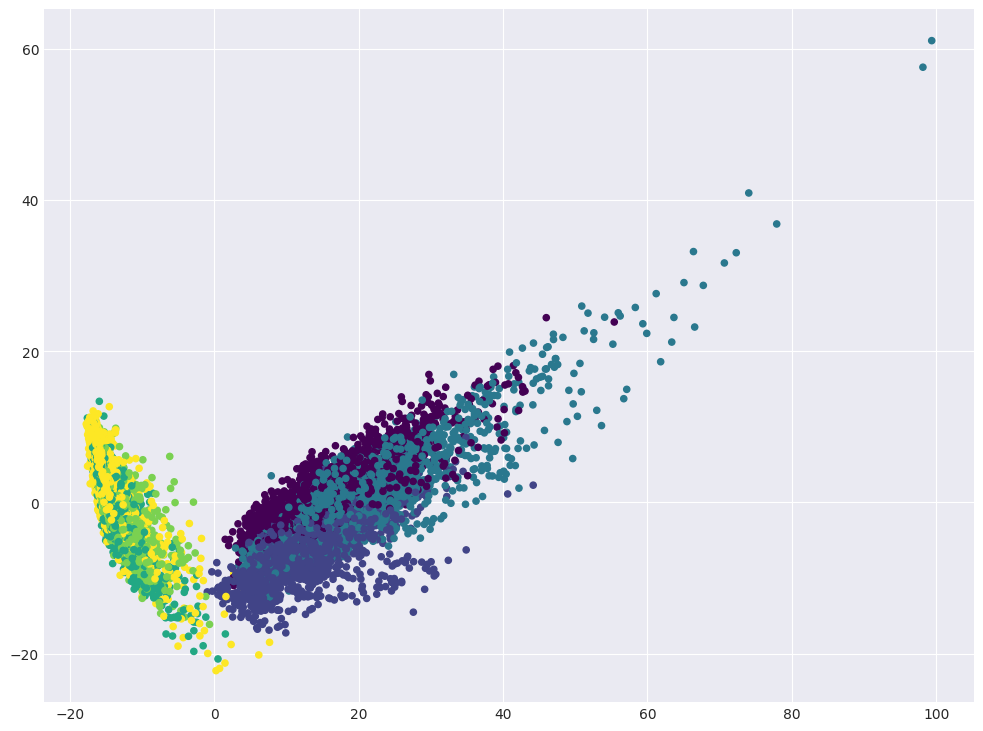

In [13]:
# Ваш код здесь
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis');

**Вопрос 3:** (0.5 баллов)

Если все получилось правильно, Вы увидите сколько-то кластеров, почти идеально отделенных друг от друга. Какие виды активности входят в эти кластеры?<br>

**Ответ:**
- 2 кластера: (ходьба, подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)

------------------------------

**Задание 1.** (1 балл)

Сделайте кластеризацию данных методом `KMeans` (собственная имплементация и готовая реализация), обучив модель на данных со сниженной за счет PCA размерностью. В данном случае мы подскажем, что нужно искать именно 6 кластеров, но в общем случае мы не будем знать, сколько кластеров надо искать.

Параметры:

- **n_clusters** = n_classes (число уникальных меток целевого класса)
- **n_init** = 100
- **random_state** = RANDOM_STATE (для воспроизводимости результата)

Остальные параметры со значениями по умолчанию.

In [14]:
# Ваш код здесь
kmeans = KMeans(
    n_clusters=n_classes,
    n_init=100,
    random_state=RANDOM_STATE
)
cluster_labels = kmeans.fit_predict(X_pca)

Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

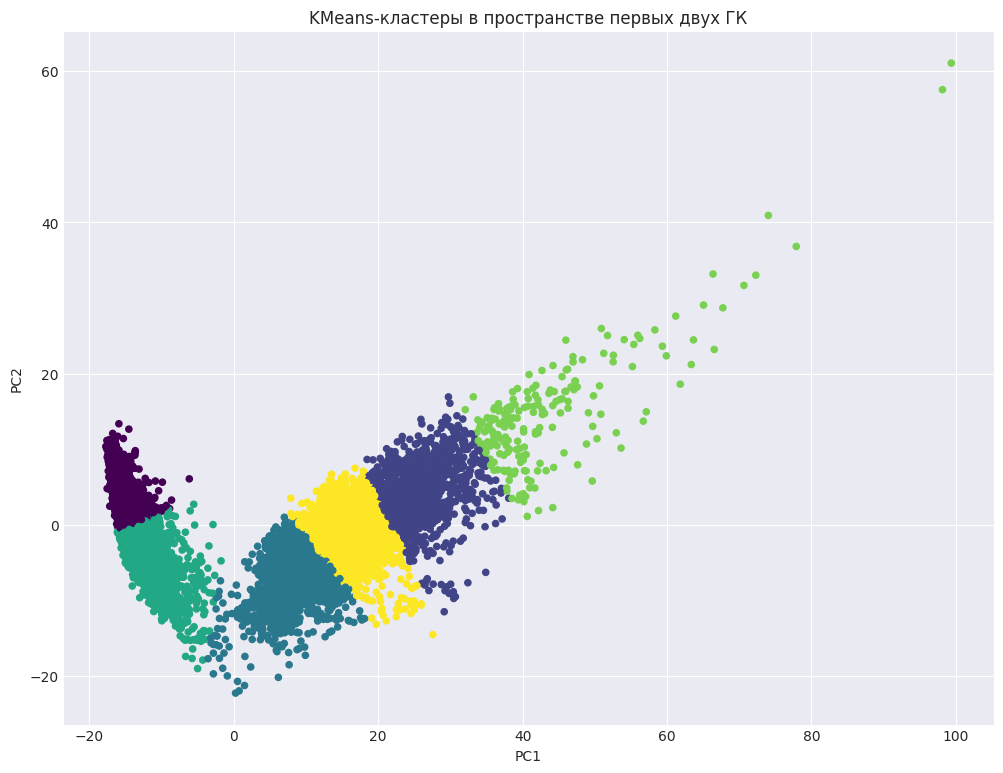

In [15]:
# Ваш код здесь
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=20, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans-кластеры в пространстве первых двух ГК");

Посмотрите на соответствие между метками кластеров и исходными метками классов и на то, какие виды активностей алгоритм `KMeans` путает.

In [16]:
tab = pd.crosstab(y, cluster_labels, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице',
             'спуск по лестнице', 'сидение', 'стояние', 'лежание', 'все']
tab.columns = ['cluster' + str(i + 1) for i in range(6)] + ['все']
tab

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,все
ходьба,0,406,431,0,39,846,1722
подъем вверх по лестнице,0,115,1011,0,2,416,1544
спуск по лестнице,0,586,162,0,162,496,1406
сидение,1117,0,15,645,0,0,1777
стояние,972,0,2,932,0,0,1906
лежание,1366,0,26,552,0,0,1944
все,3455,1107,1647,2129,203,1758,10299


Видим, что каждому классу (т.е. каждой активности) соответствуют несколько кластеров. Давайте посмотрим на максимальную долю объектов в классе, отнесенных к какому-то одному кластеру. Это будет простой метрикой, характеризующей, насколько легко класс отделяется от других при кластеризации.

Пример: если для класса "спуск по лестнице", в котором 1406 объектов,  распределение кластеров такое:
 - кластер 1 – 900
 - кластер 3 – 500
 - кластер 6 – 6,

то такая доля будет 900 / 1406 $\approx$ 0.64.


**Вопрос 4:** (1 балл)

Какой вид активности отделился от остальных лучше всего в терминах простой  метрики, описанной выше?<br>

**Ответ:**
- перечисленные варианты не подходят

Видно, что kMeans не очень хорошо отличает только активности друг от друга. Используйте метод локтя, чтобы выбрать оптимальное количество кластеров. Параметры алгоритма и данные используем те же, что раньше, меняем только `n_clusters`.

/tmp/ipython-input-1349707816.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(ks):


  0%|          | 0/6 [00:00<?, ?it/s]

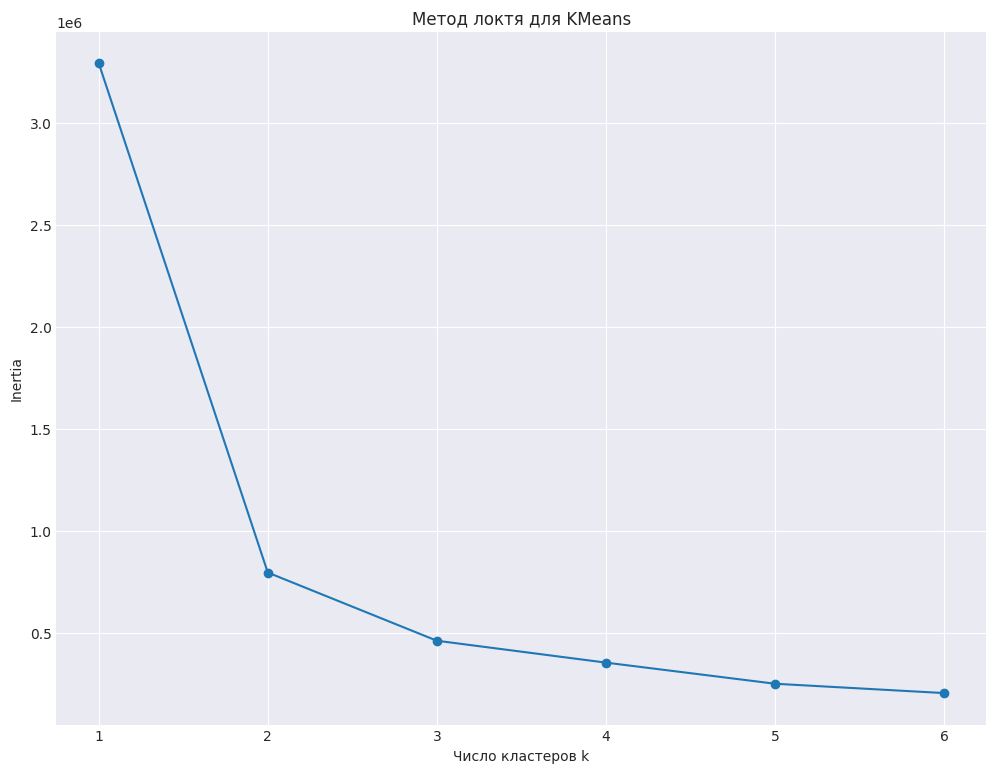

In [17]:
# Ваш код здесь
inertia = []
ks = range(1, n_classes + 1)

for k in tqdm_notebook(ks):
    km = KMeans(
        n_clusters=k,
        n_init=100,
        random_state=RANDOM_STATE
    )
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.plot(list(ks), inertia, marker='o')
plt.xlabel('Число кластеров k')
plt.ylabel('Inertia')
plt.title('Метод локтя для KMeans');

**Вопрос 5:** (1 балл)

Какое количество кластеров оптимально выбрать, согласно методу локтя?<br>

**Ответ:**
- 2

------------------------

Попробуем еще один метод кластеризации, который описывался в статье – агломеративную кластеризацию.

In [18]:
ag = AgglomerativeClustering(n_clusters=n_classes,
                             linkage='ward').fit(X_pca)

Посчитайте Adjusted Rand Index (`sklearn.metrics`) для получившегося разбиения на кластеры и для `KMeans` с параметрами из задания к 4 вопросу.

In [19]:
# Ваш код здесь
ari_kmeans = adjusted_rand_score(y, cluster_labels)
ari_ag = adjusted_rand_score(y, ag.labels_)

print("KMeans: ARI =", ari_kmeans)
print("Agglomerative Clustering: ARI =", ari_ag)

KMeans: ARI = 0.27412153957071983
Agglomerative Clustering: ARI = 0.2625750496345055


**Вопрос 6:** (1 балл)

Отметьте все верные утверждения.<br>

**Ответ:**
- Для ARI не имеет значения какие именно метки присвоены кластерам, имеет значение только разбиение объектов на кластеры
- В случае случайного разбиения на кластеры ARI будет близок к нулю

-------------------------------

Можно заметить, что задача не очень хорошо решается именно как задача кластеризации, если выделять несколько кластеров (> 2). Давайте теперь решим задачу классификации, вспомнив, что данные у нас размечены.  

Для классификации используйте метод опорных векторов – класс `sklearn.svm.LinearSVC`. Мы в курсе отдельно не рассматривали этот алгоритм, но он очень известен, почитать про него можно, например, в материалах Евгения Соколова –  [тут](https://github.com/esokolov/ml-course-msu/blob/master/ML16/lecture-notes/Sem11_linear.pdf).

Настройте для `LinearSVC` гиперпараметр `C` с помощью `GridSearchCV`.

- Обучите новый `StandardScaler` на обучающей выборке (со всеми исходными признаками), прмиените масштабирование к тестовой выборке
- В `GridSearchCV` укажите  cv=3.

In [20]:
# Ваш код здесь
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10]}

In [22]:
# Ваш код здесь
best_svc = GridSearchCV(
    svc,
    svc_params,
    cv=3,
    n_jobs=-1
)

In [23]:
# Ваш код здесь
best_svc.fit(X_train_scaled, y_train)

best_svc.best_params_, best_svc.best_score_

({'C': 0.1}, np.float64(0.9379785010699506))

**Вопрос 7** (0.5 баллов)

Какое значение гиперпараметра `C` было выбрано лучшим по итогам кросс-валидации?<br>

**Ответ:**
- 0.1

In [24]:
y_predicted = best_svc.predict(X_test_scaled)

In [25]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице',
             'сидение', 'стояние', 'лежание', 'все']
tab.columns = tab.index
tab

,ходьба,подъем вверх по лестнице,спуск по лестнице,сидение,стояние,лежание,все
ходьба,494,2,0,0,0,0,496
подъем вверх по лестнице,12,459,0,0,0,0,471
спуск по лестнице,2,4,413,1,0,0,420
сидение,0,4,0,426,61,0,491
стояние,0,0,0,15,517,0,532
лежание,0,0,0,0,11,526,537
все,508,469,413,442,589,526,2947


**Вопрос 8:** (0.5 балл)

Какой вид активности SVM определяет хуже всего в терминах точности? Полноты? <br>

**Ответ:**
- по точности – сидение, по полноте – стояние

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10]}

best_svc_pca = GridSearchCV(svc, svc_params, cv=3, n_jobs=-1)
best_svc_pca.fit(X_train_pca, y_train)

best_svc_pca.best_params_, best_svc_pca.best_score_

diff = round(100 * (best_svc.best_score_ - best_svc_pca.best_score_))
diff

4

Наконец, проделайте то же самое, что в 7 вопросе, только добавив PCA.

- Используйте выборки `X_train_scaled` и `X_test_scaled`
- Обучите тот же PCA, что раньше, на отмасшабированной обучающей выборке, примените преобразование к тестовой
- Настройте гиперпараметр `C` на кросс-валидации по обучающей выборке с PCA-преобразованием. Вы заметите, насколько это проходит быстрее, чем раньше.

**Вопрос 9:** (1 балл)

Какова разность между лучшим качеством (долей верных ответов) на кросс-валидации в случае всех 561 исходных признаков и во втором случае, когда применялся метод главных компонент? Округлите до целых процентов.<br>

**Ответ:**
- 4%


**Вопрос 10:** (1 балл)

Выберите все верные утверждения:

**Ответ:**
- PCA можно использовать для визуализации данных, однако для этой задачи есть и лучше подходящие методы, например, tSNE. Зато PCA имеет меньшую вычислительную сложность
- PCA строит линейные комбинации исходных признаков, и в некоторых задачах они могут плохо интерпретироваться человеком

**Задание 2.** (1 балл)

Попробуйте использовать DBSCAN в качестве алгоритма кластеризации и метод понижения размерности tSNE.

In [27]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(X_scaled)
X_tsne.shape

(10299, 2)

In [28]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_tsne)

unique_labels, counts = np.unique(db_labels, return_counts=True)
list(zip(unique_labels, counts))

[(np.int64(-1), np.int64(4766)),
 (np.int64(0), np.int64(11)),
 (np.int64(1), np.int64(14)),
 (np.int64(2), np.int64(18)),
 (np.int64(3), np.int64(42)),
 (np.int64(4), np.int64(9)),
 (np.int64(5), np.int64(72)),
 (np.int64(6), np.int64(178)),
 (np.int64(7), np.int64(30)),
 (np.int64(8), np.int64(91)),
 (np.int64(9), np.int64(24)),
 (np.int64(10), np.int64(14)),
 (np.int64(11), np.int64(53)),
 (np.int64(12), np.int64(65)),
 (np.int64(13), np.int64(17)),
 (np.int64(14), np.int64(51)),
 (np.int64(15), np.int64(12)),
 (np.int64(16), np.int64(33)),
 (np.int64(17), np.int64(48)),
 (np.int64(18), np.int64(12)),
 (np.int64(19), np.int64(18)),
 (np.int64(20), np.int64(20)),
 (np.int64(21), np.int64(14)),
 (np.int64(22), np.int64(12)),
 (np.int64(23), np.int64(18)),
 (np.int64(24), np.int64(12)),
 (np.int64(25), np.int64(30)),
 (np.int64(26), np.int64(65)),
 (np.int64(27), np.int64(55)),
 (np.int64(28), np.int64(14)),
 (np.int64(29), np.int64(10)),
 (np.int64(30), np.int64(17)),
 (np.int64(31), 

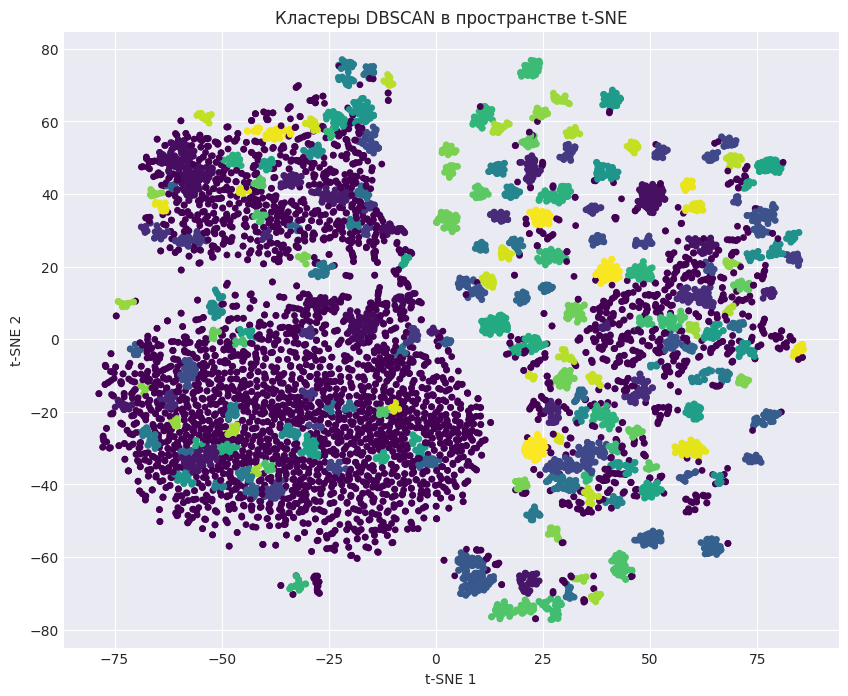

In [29]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=db_labels, s=15, cmap='viridis')
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Кластеры DBSCAN в пространстве t-SNE");

In [30]:
from sklearn.metrics import adjusted_rand_score

ari_dbscan = adjusted_rand_score(y, db_labels)
ari_dbscan

0.1058310323436756